# Word Embedding Interactive Lab

**Welcome to the Word Embedding Lab!**

In this session, you'll learn how computers represent and "understand" word meanings through hands-on experiments with pre-trained word embedding models.

---

## Lab Overview

**Duration:** 50 minutes

**Learning Objectives:**
- Understand word embeddings as numerical representations of words
- Use pre-trained models (Word2Vec, GloVe, BERT) to analyze word relationships
- Compare static vs. contextualized embeddings

---

## Session Structure

1. **Environment Setup** (5 min)
2. **Introduction: Word Arithmetic** (5 min)
3. **Visual Exploration** (5 min)
4. **Word2Vec Experiments** (10 min)
5. **GloVe Experiments** (5 min)
6. **BERT Embeddings** (15 min)
7. **Comparison & Discussion** (5 min)
8. **Wrap-up** (5 min)

---

---

## Part 0: Environment Setup

Run the following cells to install necessary libraries and load models. This may take several minutes.

In [1]:
# Install required packages
!pip install gensim transformers torch scikit-learn matplotlib plotly -q

print("Libraries installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 15.0 MB/s eta 0:00:00
Libraries installed successfully.


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted.")

Mounted at /content/drive
Google Drive mounted.


In [3]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine
from gensim.models import KeyedVectors
import torch
from transformers import BertTokenizer, BertModel
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("All libraries imported successfully.")

All libraries imported successfully.


---

## Part 1: Introduction - Word Arithmetic Magic

Before diving into the theory, let's observe something remarkable about how computers represent words.

**Question to ponder:** If we could do arithmetic with words, what would "King - Man + Woman" equal?

In [4]:
# Load Word2Vec model
# Note: This step takes 2-3 minutes due to large model size (~3.6GB)

print("Loading Word2Vec model... Please wait.")

model_path = '/content/drive/MyDrive/tutorial_data/GoogleNews-vectors-negative300.bin.gz'
word2vec_model = KeyedVectors.load_word2vec_format(model_path, binary=True)

print(f"Model loaded successfully.")
print(f"Vocabulary size: {len(word2vec_model):,} words")
print(f"Vector dimension: {word2vec_model.vector_size}")

Loading Word2Vec model... Please wait.
Model loaded successfully.
Vocabulary size: 3,000,000 words
Vector dimension: 300


In [5]:
# Word analogy demonstration

def word_analogy(model, positive, negative, topn=5):
    """
    Perform word analogy: positive[0] - negative[0] + positive[1] ≈ ?

    Args:
        model: Word embedding model
        positive: List of words to add
        negative: List of words to subtract
        topn: Number of results to return
    """
    try:
        results = model.most_similar(positive=positive, negative=negative, topn=topn)
        return results
    except KeyError as e:
        return f"Error: Word {e} not in vocabulary"

# Classic example: King - Man + Woman = ?
print("Example: King - Man + Woman = ?")
print("-" * 60)

results = word_analogy(word2vec_model,
                       positive=['king', 'woman'],
                       negative=['man'],
                       topn=5)

print("Top results:")
for i, (word, similarity) in enumerate(results, 1):
    print(f"{i}. {word:20s} (similarity: {similarity:.4f})")

print("\nObservation: The computer 'knows' that queen is the female counterpart of king.")

Example: King - Man + Woman = ?
------------------------------------------------------------
Top results:
1. queen                (similarity: 0.7118)
2. monarch              (similarity: 0.6190)
3. princess             (similarity: 0.5902)
4. crown_prince         (similarity: 0.5499)
5. prince               (similarity: 0.5377)

Observation: The computer 'knows' that queen is the female counterpart of king.


In [6]:
# More examples of word analogies

examples = [
    {
        'description': 'Geographic relation',
        'positive': ['Paris', 'Italy'],
        'negative': ['France'],
        'expected': 'Rome'
    },
    {
        'description': 'Verb tense',
        'positive': ['walking', 'swim'],
        'negative': ['walk'],
        'expected': 'swimming'
    },
    {
        'description': 'Comparative adjective',
        'positive': ['good', 'larger'],
        'negative': ['large'],
        'expected': 'better'
    }
]

for example in examples:
    print(f"\n{example['description']}")
    pos_str = ' + '.join(example['positive'])
    neg_str = ' - '.join(example['negative'])
    print(f"Query: {pos_str} - {neg_str}")
    print(f"Expected: {example['expected']}")

    results = word_analogy(word2vec_model,
                          example['positive'],
                          example['negative'],
                          topn=3)

    print("Results:")
    for i, (word, similarity) in enumerate(results, 1):
        print(f"  {i}. {word} ({similarity:.3f})")
    print("-" * 60)


Geographic relation
Query: Paris + Italy - France
Expected: Rome
Results:
  1. Milan (0.722)
  2. Rome (0.703)
  3. Palermo_Sicily (0.597)
------------------------------------------------------------

Verb tense
Query: walking + swim - walk
Expected: swimming
Results:
  1. swimming (0.825)
  2. swam (0.681)
  3. swims (0.654)
------------------------------------------------------------

Comparative adjective
Query: good + larger - large
Expected: better
Results:
  1. better (0.773)
  2. nicer (0.594)
  3. stronger (0.568)
------------------------------------------------------------


### Discussion Point

**Question:** How can computers perform "arithmetic" on words?

**Key Insight:** Words are represented as vectors (lists of numbers). The word arithmetic operations are actually vector additions and subtractions in high-dimensional space.

---

## Part 2: Visual Exploration - Understanding Vector Space

Let's visualize what word vectors look like and how they organize semantically similar words.

In the GoogleNews Word2Vec model, each word is represented as a point in 300-dimensional space. While we cannot visualize 300 dimensions directly, we can use dimensionality reduction techniques (PCA, t-SNE) to project into 2D or 3D.

In [7]:
# Examine a word vector

word = 'king'
vector = word2vec_model[word]

print(f"Word: '{word}'")
print(f"Vector dimension: {len(vector)}")
print(f"\nFirst 20 values of vector:")
print(vector[:20])
print(f"\nThese {len(vector)} numbers represent the computer's 'understanding' of '{word}'.")

Word: 'king'
Vector dimension: 300

First 20 values of vector:
[ 0.12597656  0.02978516  0.00860596  0.13964844 -0.02563477 -0.03613281
  0.11181641 -0.19824219  0.05126953  0.36328125 -0.2421875  -0.30273438
 -0.17773438 -0.02490234 -0.16796875 -0.16992188  0.03466797  0.00521851
  0.04638672  0.12890625]

These 300 numbers represent the computer's 'understanding' of 'king'.


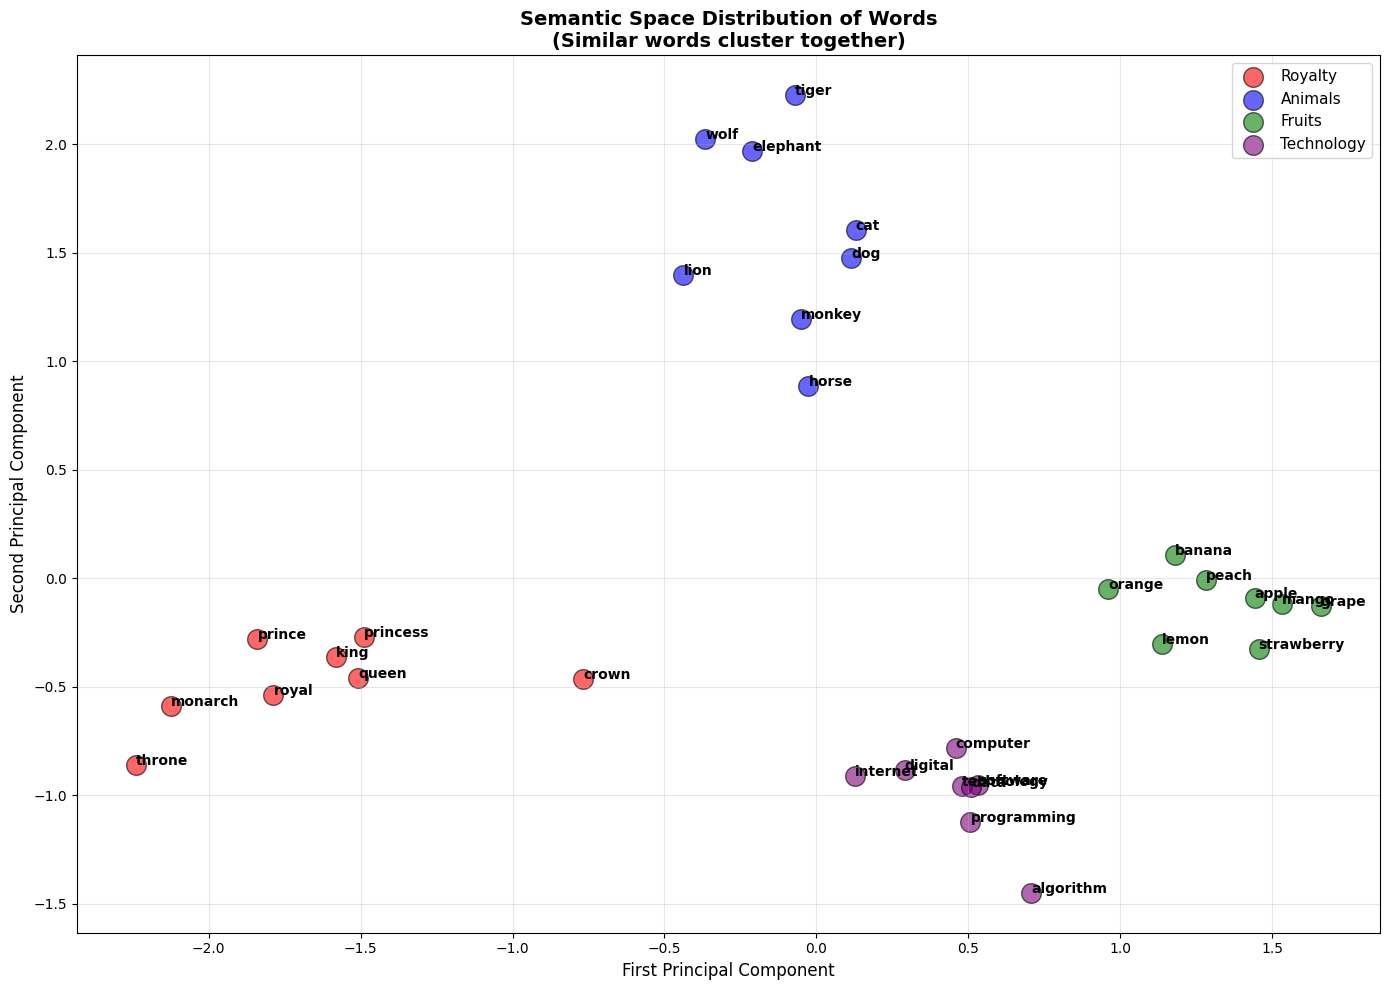




Observation: Words from the same semantic category cluster together in vector space.


In [32]:
# Visualize word clusters in 2D space

# Define word categories
word_categories = {
    'Royalty': ['king', 'queen', 'prince', 'princess', 'royal', 'throne', 'crown', 'monarch'],
    'Animals': ['cat', 'dog', 'lion', 'tiger', 'elephant', 'monkey', 'horse', 'wolf'],
    'Fruits': ['apple', 'banana', 'orange', 'grape', 'strawberry', 'mango', 'peach', 'lemon'],
    'Technology': ['computer', 'software', 'internet', 'technology', 'digital', 'programming', 'algorithm', 'data']
}

# Collect vectors
all_words = []
all_vectors = []
word_labels = []
colors_map = {'Royalty': 'red', 'Animals': 'blue', 'Fruits': 'green', 'Technology': 'purple'}

for category, words in word_categories.items():
    for word in words:
        if word in word2vec_model:
            all_words.append(word)
            all_vectors.append(word2vec_model[word])
            word_labels.append(category)

# Apply PCA to reduce to 2D
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(all_vectors)

# Create visualization
plt.figure(figsize=(14, 10))

for category, color in colors_map.items():
    indices = [i for i, label in enumerate(word_labels) if label == category]
    category_vectors = vectors_2d[indices]

    plt.scatter(category_vectors[:, 0], category_vectors[:, 1],
               c=color, label=category, s=200, alpha=0.6, edgecolors='black')

    for idx in indices:
        plt.annotate(all_words[idx],
                    (vectors_2d[idx, 0], vectors_2d[idx, 1]),
                    fontsize=10, fontweight='bold')

plt.title('Semantic Space Distribution of Words\n(Similar words cluster together)',
         fontsize=14, fontweight='bold')
plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n\n\nObservation: Words from the same semantic category cluster together in vector space.")

---

## Part 3: Word2Vec Experiments

Now that you understand the basics, complete the following tasks to explore Word2Vec in depth.

### Background: Word2Vec

Word2Vec is a neural network-based algorithm that learns word embeddings from large text corpora. It uses one of two architectures:

1. **CBOW (Continuous Bag of Words):** Predicts target word from context words
2. **Skip-gram:** Predicts context words from target word

The model you loaded was trained on ~100 billion words from Google News.

---

### Task 1: Explore Word Similarities

Find words most similar to given query words.

In [13]:
# Task 1: Find similar words

# TODO: Choose 3 words you're interested in exploring
query_words = ['____', '____', '____']  # Replace with your words

for word in query_words:
    if word in word2vec_model:
        print(f"\nWords most similar to '{word}':")
        print("-" * 60)

        # TODO: Use word2vec_model.most_similar() to find top 5 similar words
        # similar_words = ...

        # TODO: Print results with similarity scores
        # for i, (similar_word, score) in enumerate(similar_words, 1):
        #     print(...)
    else:
        print(f"\nWord '{word}' not found in vocabulary. Try another word.")


Words most similar to '____':
------------------------------------------------------------

Words most similar to '____':
------------------------------------------------------------

Words most similar to '____':
------------------------------------------------------------


**Reference Solution:**

In [14]:
query_words = ['happiness', 'computer', 'ocean']

for word in query_words:
    if word in word2vec_model:
        print(f"\nWords most similar to '{word}':")
        print("-" * 60)

        similar_words = word2vec_model.most_similar(word, topn=5)

        for i, (similar_word, score) in enumerate(similar_words, 1):
            print(f"{i}. {similar_word:20s} Similarity: {score:.4f}")


Words most similar to 'happiness':
------------------------------------------------------------
1. contentment          Similarity: 0.7695
2. joy                  Similarity: 0.6183
3. Happiness            Similarity: 0.6116
4. hapiness             Similarity: 0.5749
5. contentedness        Similarity: 0.5575

Words most similar to 'computer':
------------------------------------------------------------
1. computers            Similarity: 0.7979
2. laptop               Similarity: 0.6640
3. laptop_computer      Similarity: 0.6549
4. Computer             Similarity: 0.6473
5. com_puter            Similarity: 0.6082

Words most similar to 'ocean':
------------------------------------------------------------
1. sea                  Similarity: 0.7644
2. oceans               Similarity: 0.7483
3. Pacific_Ocean        Similarity: 0.7037
4. Atlantic_Ocean       Similarity: 0.6659
5. oceanic              Similarity: 0.6610


### Task 2: Create Your Own Analogies

Design word analogy problems and test if the model captures these relationships.

In [33]:
# Task 2: Word analogies

# Example provided
print("Example: Tokyo - Japan + France = ?\n")
result = word2vec_model.most_similar(positive=['Tokyo', 'France'], negative=['Japan'], topn=3)
for i, (word, score) in enumerate(result, 1):
    print(f"{i}. {word:15s} ({score:.4f})")

print("\n" + "="*70 + "\n")

# TODO: Design and test 3 analogies of your own
# Consider relationships: geography, professions, grammar, opposites, etc.

# Analogy 1:
print("Analogy 1: ___ - ___ + ___ = ?\n")
# result1 = word2vec_model.most_similar(positive=[...], negative=[...], topn=3)
# Print results

print("\n" + "-"*70 + "\n")

# Analogy 2:
print("Analogy 2: ___ - ___ + ___ = ?\n")
# Your code here

print("\n" + "-"*70 + "\n")

# Analogy 3:
print("Analogy 3: ___ - ___ + ___ = ?\n")
# Your code here

Example: Tokyo - Japan + France = ?

1. Paris           (0.8100)
2. French          (0.6447)
3. Colombes        (0.6279)


Analogy 1: ___ - ___ + ___ = ?


----------------------------------------------------------------------

Analogy 2: ___ - ___ + ___ = ?


----------------------------------------------------------------------

Analogy 3: ___ - ___ + ___ = ?



**Reflection Questions:**

In [17]:
# Task 2: Word analogies - REFERENCE SOLUTION

# Example provided
print("Example: Tokyo - Japan + France = ?\n")
result = word2vec_model.most_similar(positive=['Tokyo', 'France'], negative=['Japan'], topn=3)
for i, (word, score) in enumerate(result, 1):
    print(f"{i}. {word:15s} ({score:.4f})")

print("\n" + "="*70 + "\n")

# Analogy 1: Verb tense (present → past)
print("Analogy 1: walked - walk + swim = ? (Grammar: past tense)\n")
result1 = word2vec_model.most_similar(positive=['walked', 'swim'], negative=['walk'], topn=3)
for i, (word, score) in enumerate(result1, 1):
    print(f"{i}. {word:15s} ({score:.4f})")
print("\nExpected: 'swam' (past tense of swim)")

print("\n" + "-"*70 + "\n")

# Analogy 2: Comparative adjectives
print("Analogy 2: bigger - big + small = ? (Comparative form)\n")
result2 = word2vec_model.most_similar(positive=['bigger', 'small'], negative=['big'], topn=3)
for i, (word, score) in enumerate(result2, 1):
    print(f"{i}. {word:15s} ({score:.4f})")
print("\nExpected: 'smaller' (comparative of small)")

print("\n" + "-"*70 + "\n")

# Analogy 3: Professional relationships
print("Analogy 3: doctor - hospital + school = ? (Professional context)\n")
result3 = word2vec_model.most_similar(positive=['doctor', 'school'], negative=['hospital'], topn=3)
for i, (word, score) in enumerate(result3, 1):
    print(f"{i}. {word:15s} ({score:.4f})")
print("\nExpected: 'teacher' (professional who works in school)")

print("\n" + "="*70 + "\n")

# Additional examples students might try:
print("MORE EXAMPLE ANALOGIES TO EXPLORE:\n")

examples = [
    {
        'name': 'Country-Currency',
        'positive': ['dollar', 'Japan'],
        'negative': ['America'],
        'expected': 'yen'
    },
    {
        'name': 'Animal-Sound',
        'positive': ['bark', 'cat'],
        'negative': ['dog'],
        'expected': 'meow'
    },
    {
        'name': 'Opposite Gender',
        'positive': ['actor', 'woman'],
        'negative': ['man'],
        'expected': 'actress'
    },
    {
        'name': 'Plural Form',
        'positive': ['geese', 'mouse'],
        'negative': ['goose'],
        'expected': 'mice'
    },
    {
        'name': 'Tool-Action',
        'positive': ['cut', 'pen'],
        'negative': ['knife'],
        'expected': 'write'
    }
]

for example in examples:
    print(f"\n{example['name']}: ", end="")
    pos = " + ".join(example['positive'])
    neg = " - ".join(example['negative'])
    print(f"{pos} - {neg}")

    result = word2vec_model.most_similar(
        positive=example['positive'],
        negative=example['negative'],
        topn=3
    )

    print(f"Expected: '{example['expected']}'")
    print("Results:")
    for i, (word, score) in enumerate(result, 1):
        marker = " ✓" if word == example['expected'] else ""
        print(f"  {i}. {word:15s} ({score:.4f}){marker}")

Example: Tokyo - Japan + France = ?

1. Paris           (0.8100)
2. French          (0.6447)
3. Colombes        (0.6279)


Analogy 1: walked - walk + swim = ? (Grammar: past tense)

1. swam            (0.7906)
2. swimming        (0.6664)
3. swum            (0.6417)

Expected: 'swam' (past tense of swim)

----------------------------------------------------------------------

Analogy 2: bigger - big + small = ? (Comparative form)

1. larger          (0.7402)
2. smaller         (0.7330)
3. tiny            (0.5698)

Expected: 'smaller' (comparative of small)

----------------------------------------------------------------------

Analogy 3: doctor - hospital + school = ? (Professional context)

1. guidance_counselor (0.5970)
2. teacher         (0.5755)
3. eighth_grade    (0.5226)

Expected: 'teacher' (professional who works in school)


MORE EXAMPLE ANALOGIES TO EXPLORE:


Country-Currency: dollar + Japan - America
Expected: 'yen'
Results:
  1. yen             (0.6260) ✓
  2. Japanese_Yen

**Reflection Questions:**
1. Which analogies worked well? Which didn't?

→ Analogies with frequent patterns in text (gender, tense) work best

2. Why might certain relationships be better captured than others?

→ Less common relationships or ambiguous contexts may fail

3. What does this tell you about the training data?

→ The model learns relationships that appear consistently in Google News

### Task 3: Similarity Calculation and Comparison

Calculate cosine similarity between word pairs and visualize the results.

In [ ]:
# Task 3: Calculate and visualize similarity scores

# TODO: Define 6 word pairs to compare
word_pairs = [
    ('____', '____'),  # Similar words
    ('____', '____'),  # Similar words
    ('____', '____'),  # Somewhat related
    ('____', '____'),  # Somewhat related
    ('____', '____'),  # Unrelated
    ('____', '____'),  # Unrelated or opposite
]

# TODO: Calculate similarities
similarities = []
labels = []

for word1, word2 in word_pairs:
    if word1 in word2vec_model and word2 in word2vec_model:
        # TODO: Calculate cosine similarity using word2vec_model.similarity()
        # similarity = ...
        # similarities.append(similarity)
        labels.append(f"{word1} - {word2}")
        # print(f"{word1:15s} - {word2:15s} : {similarity:.4f}")

# TODO: Create a horizontal bar chart
# plt.figure(figsize=(12, 6))
# colors = ['green' if s > 0.5 else 'orange' if s > 0 else 'red' for s in similarities]
# plt.barh(labels, similarities, color=colors)
# plt.xlabel('Similarity Score')
# plt.title('Word Pair Similarity Comparison')
# plt.xlim(-0.5, 1.0)
# plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)
# plt.grid(axis='x', alpha=0.3)
# plt.tight_layout()
# plt.show()

**Reference Solution:**

king            - queen           : 0.6511
happy           - joyful          : 0.4238
doctor          - hospital        : 0.5143
tree            - forest          : 0.4218
cat             - mathematics     : 0.0022


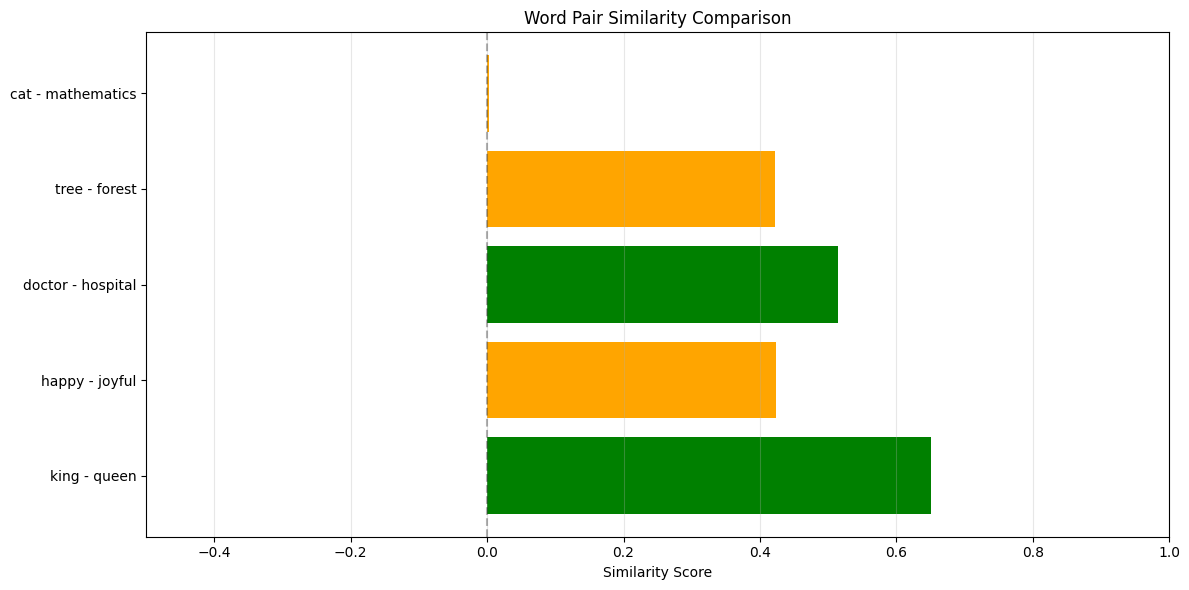

In [35]:
word_pairs = [
    ('king', 'queen'),
    ('happy', 'joyful'),
    ('doctor', 'hospital'),
    ('tree', 'forest'),
    ('cat', 'mathematics'),
]

similarities = []
labels = []

for word1, word2 in word_pairs:
    if word1 in word2vec_model and word2 in word2vec_model:
        similarity = word2vec_model.similarity(word1, word2)
        similarities.append(similarity)
        labels.append(f"{word1} - {word2}")
        print(f"{word1:15s} - {word2:15s} : {similarity:.4f}")

plt.figure(figsize=(12, 6))
colors = ['green' if s > 0.5 else 'orange' if s > 0 else 'red' for s in similarities]
plt.barh(labels, similarities, color=colors)
plt.xlabel('Similarity Score')
plt.title('Word Pair Similarity Comparison')
plt.xlim(-0.5, 1.0)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Part 4: GloVe Experiments

### Background: GloVe (Global Vectors for Word Representation)

GloVe is another popular word embedding method developed at Stanford. Unlike Word2Vec's predictive approach, GloVe uses matrix factorization on word co-occurrence statistics.

**Key difference from Word2Vec:**
- Word2Vec: Local context window (predicts nearby words)
- GloVe: Global corpus statistics (analyzes word co-occurrence across entire corpus)

Let's load and explore GloVe embeddings.

In [21]:
# Load GloVe embeddings

def load_glove_embeddings(file_path):
    """
    Load GloVe embeddings from text file.

    Args:
        file_path: Path to GloVe text file

    Returns:
        Dictionary mapping words to vectors
    """
    embeddings = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

print("Loading GloVe embeddings...")
glove_path = '/content/drive/MyDrive/tutorial_data/glove.6B.50d.txt'
glove_embeddings = load_glove_embeddings(glove_path)

print(f"GloVe embeddings loaded successfully.")
print(f"Vocabulary size: {len(glove_embeddings):,} words")
print(f"Vector dimension: {len(next(iter(glove_embeddings.values())))}")

Loading GloVe embeddings...
GloVe embeddings loaded successfully.
Vocabulary size: 400,000 words
Vector dimension: 50


In [22]:
# Helper function for GloVe similarity search

def find_most_similar_glove(word, embeddings, n=5):
    """
    Find most similar words using cosine similarity.

    Args:
        word: Query word
        embeddings: GloVe embeddings dictionary
        n: Number of results to return

    Returns:
        List of (word, similarity) tuples
    """
    if word not in embeddings:
        return None

    word_vec = embeddings[word]
    similarities = {}

    for other_word, other_vec in embeddings.items():
        if other_word != word:
            similarity = 1 - cosine(word_vec, other_vec)
            similarities[other_word] = similarity

    # Sort by similarity
    sorted_words = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
    return sorted_words[:n]

# Test the function
test_word = 'king'
print(f"Words most similar to '{test_word}' in GloVe:")
results = find_most_similar_glove(test_word, glove_embeddings, n=5)
for i, (word, similarity) in enumerate(results, 1):
    print(f"{i}. {word:15s} {similarity:.4f}")

Words most similar to 'king' in GloVe:
1. prince          0.8236
2. queen           0.7839
3. ii              0.7746
4. emperor         0.7736
5. son             0.7667


### Task 4: Compare Word2Vec and GloVe

For the same query words, compare results from Word2Vec and GloVe.

In [23]:
# Task 4: Compare Word2Vec and GloVe results

# TODO: Choose 3 words to compare
comparison_words = ['happiness', 'computer', 'ocean']

for word in comparison_words:
    print(f"\n{'='*70}")
    print(f"Query word: '{word}'")
    print(f"{'='*70}\n")

    # Word2Vec results
    if word in word2vec_model:
        print("Word2Vec results:")
        w2v_results = word2vec_model.most_similar(word, topn=5)
        for i, (w, score) in enumerate(w2v_results, 1):
            print(f"  {i}. {w:20s} {score:.4f}")
    else:
        print("Word2Vec: Word not in vocabulary")

    print()

    # GloVe results
    if word in glove_embeddings:
        print("GloVe results:")
        glove_results = find_most_similar_glove(word, glove_embeddings, n=5)
        for i, (w, score) in enumerate(glove_results, 1):
            print(f"  {i}. {w:20s} {score:.4f}")
    else:
        print("GloVe: Word not in vocabulary")

print("\n" + "="*70)
print("\nReflection: Do Word2Vec and GloVe give similar results?")
print("What differences do you notice?")


Query word: 'happiness'

Word2Vec results:
  1. contentment          0.7695
  2. joy                  0.6183
  3. Happiness            0.6116
  4. hapiness             0.5749
  5. contentedness        0.5575

GloVe results:
  1. sake                 0.7692
  2. kindness             0.7673
  3. joy                  0.7658
  4. passion              0.7605
  5. enjoyment            0.7552

Query word: 'computer'

Word2Vec results:
  1. computers            0.7979
  2. laptop               0.6640
  3. laptop_computer      0.6549
  4. Computer             0.6473
  5. com_puter            0.6082

GloVe results:
  1. computers            0.9165
  2. software             0.8815
  3. technology           0.8526
  4. electronic           0.8126
  5. internet             0.8060

Query word: 'ocean'

Word2Vec results:
  1. sea                  0.7644
  2. oceans               0.7483
  3. Pacific_Ocean        0.7037
  4. Atlantic_Ocean       0.6659
  5. oceanic              0.6610

GloVe results:


### Task 5: GloVe Analogy Task

Implement word analogy for GloVe embeddings.

In [24]:
# Task 5: Word analogies with GloVe

def glove_analogy(embeddings, positive, negative, n=5):
    """
    Perform word analogy using GloVe embeddings.

    Args:
        embeddings: GloVe embeddings dictionary
        positive: Words to add
        negative: Words to subtract
        n: Number of results
    """
    # Calculate result vector
    result_vec = np.zeros_like(embeddings[positive[0]])

    for word in positive:
        if word in embeddings:
            result_vec += embeddings[word]

    for word in negative:
        if word in embeddings:
            result_vec -= embeddings[word]

    # Find most similar to result vector
    similarities = {}
    exclude_words = set(positive + negative)

    for word, vec in embeddings.items():
        if word not in exclude_words:
            similarity = 1 - cosine(result_vec, vec)
            similarities[word] = similarity

    sorted_words = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
    return sorted_words[:n]

# Test: King - Man + Woman = ?
print("GloVe Analogy: King - Man + Woman = ?\n")
results = glove_analogy(glove_embeddings,
                       positive=['king', 'woman'],
                       negative=['man'],
                       n=5)

for i, (word, similarity) in enumerate(results, 1):
    print(f"{i}. {word:15s} {similarity:.4f}")

print("\n" + "-"*70 + "\n")

# TODO: Try your own analogy with GloVe
print("Your analogy: ___ - ___ + ___ = ?\n")
# results = glove_analogy(glove_embeddings,
#                        positive=[...],
#                        negative=[...],
#                        n=5)
# Print results

GloVe Analogy: King - Man + Woman = ?

1. queen           0.8610
2. daughter        0.7685
3. prince          0.7641
4. throne          0.7635
5. princess        0.7513

----------------------------------------------------------------------

Your analogy: ___ - ___ + ___ = ?



---

## Part 5: BERT Embeddings

### Background: Contextualized Word Embeddings

Word2Vec and GloVe produce **static** embeddings: each word has one fixed vector regardless of context.

**Problem:** The word "bank" means different things in:
- "I deposited money at the bank" (financial institution)
- "We sat by the river bank" (land alongside water)

**Solution:** BERT (Bidirectional Encoder Representations from Transformers) produces **contextualized** embeddings: the same word gets different vectors depending on the surrounding context.

### BERT Architecture

- **Input:** Sentence with special tokens [CLS] and [SEP]
- **Processing:** Multiple transformer layers
- **Output:** Context-dependent vector for each token

Let's explore BERT embeddings.

In [25]:
# Load BERT model and tokenizer

print("Loading BERT model... This may take a minute.")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

# Set to evaluation mode
bert_model.eval()

print("BERT model loaded successfully.")
print(f"Model: bert-base-uncased")
print(f"Hidden size: {bert_model.config.hidden_size}")
print(f"Number of layers: {bert_model.config.num_hidden_layers}")

Loading BERT model... This may take a minute.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BERT model loaded successfully.
Model: bert-base-uncased
Hidden size: 768
Number of layers: 12


In [26]:
# Function to get BERT embeddings for a word in context

def get_bert_embedding(sentence, target_word):
    """
    Get BERT embedding for a target word in a sentence.

    Args:
        sentence: Input sentence containing the target word
        target_word: Word to get embedding for

    Returns:
        Embedding vector for the target word
    """
    # Tokenize
    tokens = tokenizer.tokenize(sentence.lower())

    # Find target word position
    target_word_lower = target_word.lower()
    try:
        target_idx = tokens.index(target_word_lower)
    except ValueError:
        # Word might be split into subwords
        target_idx = None
        for i, token in enumerate(tokens):
            if token.startswith(target_word_lower):
                target_idx = i
                break
        if target_idx is None:
            raise ValueError(f"Target word '{target_word}' not found in sentence")

    # Add special tokens
    tokens = ['[CLS]'] + tokens + ['[SEP]']
    target_idx += 1  # Adjust for [CLS]

    # Convert to IDs
    token_ids = tokenizer.convert_tokens_to_ids(tokens)
    tokens_tensor = torch.tensor([token_ids])

    # Get embeddings
    with torch.no_grad():
        outputs = bert_model(tokens_tensor)
        hidden_states = outputs.last_hidden_state

    # Extract embedding for target word
    word_embedding = hidden_states[0, target_idx, :].numpy()

    return word_embedding

# Test the function
sentence1 = "The king ruled the kingdom wisely."
embedding = get_bert_embedding(sentence1, "king")

print(f"Sentence: {sentence1}")
print(f"Target word: 'king'")
print(f"Embedding dimension: {len(embedding)}")
print(f"First 10 values: {embedding[:10]}")

Sentence: The king ruled the kingdom wisely.
Target word: 'king'
Embedding dimension: 768
First 10 values: [ 0.40290204  0.10291705 -0.02201474  0.10952979  0.1596547  -0.57759744
 -0.25311217  0.43623918  0.0524778  -0.6064866 ]


### Task 6: Context Matters - Demonstrating BERT's Power

Compare embeddings of the same word in different contexts.

In [27]:
# Task 6: Compare embeddings of the same word in different contexts

# Example: "bank" in different contexts
sentences_bank = [
    "I need to go to the bank to deposit money.",
    "We had a picnic by the river bank."
]

print("Example: Word 'bank' in different contexts\n")
print("="*70)

bank_embeddings = []
for i, sentence in enumerate(sentences_bank, 1):
    embedding = get_bert_embedding(sentence, "bank")
    bank_embeddings.append(embedding)
    print(f"\nContext {i}: {sentence}")
    print(f"Embedding (first 5 values): {embedding[:5]}")

# Calculate similarity between the two "bank" embeddings
similarity = 1 - cosine(bank_embeddings[0], bank_embeddings[1])
print(f"\nSimilarity between two 'bank' embeddings: {similarity:.4f}")
print("Note: Lower similarity indicates BERT recognizes different meanings.")

print("\n" + "="*70 + "\n")

# TODO: Try with another ambiguous word
# Examples of polysemous words: "play", "light", "right", "spring", "bat"

word_to_test = "____"  # Choose your word

sentences_custom = [
    "____",  # Sentence 1 with your word
    "____",  # Sentence 2 with your word (different meaning)
]

# TODO: Get embeddings for both contexts
# embedding1 = get_bert_embedding(sentences_custom[0], word_to_test)
# embedding2 = get_bert_embedding(sentences_custom[1], word_to_test)

# TODO: Calculate and print similarity
# similarity = 1 - cosine(embedding1, embedding2)
# print(f"Similarity between two '{word_to_test}' embeddings: {similarity:.4f}")

Example: Word 'bank' in different contexts


Context 1: I need to go to the bank to deposit money.
Embedding (first 5 values): [ 0.5997862  -0.09561869  0.08738755 -0.21111575  1.5239888 ]

Context 2: We had a picnic by the river bank.
Embedding (first 5 values): [ 0.6895469  -0.5723122   0.19924262 -0.13649994  0.01842701]

Similarity between two 'bank' embeddings: 0.5196
Note: Lower similarity indicates BERT recognizes different meanings.




### Task 7: Compare Static vs. Contextualized Embeddings

For the same word, compare how similar its embeddings are:
- In Word2Vec (static - always the same)
- In BERT (contextualized - changes with context)

In [28]:
# Task 7: Static vs. Contextualized comparison

# Word to test
test_word = "play"

# Two different contexts
sentence1 = "The children play in the park."
sentence2 = "We went to see a play at the theater."

print(f"Test word: '{test_word}'\n")
print("="*70)

# Word2Vec (static)
print("\n[Word2Vec - Static Embedding]")
if test_word in word2vec_model:
    w2v_vec = word2vec_model[test_word]
    print(f"Sentence 1: {sentence1}")
    print(f"Sentence 2: {sentence2}")
    print(f"\nSame embedding used in both contexts (first 5 values): {w2v_vec[:5]}")
    print(f"Self-similarity: 1.0000 (identical)")
else:
    print(f"Word '{test_word}' not in Word2Vec vocabulary")

print("\n" + "-"*70)

# BERT (contextualized)
print("\n[BERT - Contextualized Embedding]")
bert_emb1 = get_bert_embedding(sentence1, test_word)
bert_emb2 = get_bert_embedding(sentence2, test_word)

print(f"Sentence 1: {sentence1}")
print(f"Embedding 1 (first 5): {bert_emb1[:5]}")

print(f"\nSentence 2: {sentence2}")
print(f"Embedding 2 (first 5): {bert_emb2[:5]}")

bert_similarity = 1 - cosine(bert_emb1, bert_emb2)
print(f"\nSimilarity between contexts: {bert_similarity:.4f}")

print("\n" + "="*70)
print("\nConclusion:")
print("- Word2Vec: Same vector regardless of context (similarity = 1.0)")
print(f"- BERT: Different vectors for different contexts (similarity = {bert_similarity:.4f})")
print("\nBERT captures that 'play' has different meanings in these sentences.")

Test word: 'play'


[Word2Vec - Static Embedding]
Sentence 1: The children play in the park.
Sentence 2: We went to see a play at the theater.

Same embedding used in both contexts (first 5 values): [0.01226807 0.06225586 0.10693359 0.05810547 0.23828125]
Self-similarity: 1.0000 (identical)

----------------------------------------------------------------------

[BERT - Contextualized Embedding]
Sentence 1: The children play in the park.
Embedding 1 (first 5): [1.1495552  0.07305581 0.13632236 0.40044263 0.44497943]

Sentence 2: We went to see a play at the theater.
Embedding 2 (first 5): [ 0.9118755  -0.27136904 -0.05035829 -0.0593445   0.23337042]

Similarity between contexts: 0.5028


Conclusion:
- Word2Vec: Same vector regardless of context (similarity = 1.0)
- BERT: Different vectors for different contexts (similarity = 0.5028)

BERT captures that 'play' has different meanings in these sentences.


### Task 8: BERT Similarity in Context

Compare semantic similarity between words as they appear in specific sentences.

In [29]:
# Task 8: Contextual similarity with BERT

# Compare: "king" in royal context vs. "queen" in royal context
sentence_king = "The king ruled the kingdom with wisdom."
sentence_queen = "The queen wore a beautiful crown."

emb_king = get_bert_embedding(sentence_king, "king")
emb_queen = get_bert_embedding(sentence_queen, "queen")

similarity_royal = 1 - cosine(emb_king, emb_queen)

print("Comparison 1: Royal context")
print(f"Sentence 1: {sentence_king}")
print(f"Sentence 2: {sentence_queen}")
print(f"Similarity (king vs queen): {similarity_royal:.4f}")

print("\n" + "-"*70 + "\n")

# Compare: "apple" (fruit) vs. "apple" (company)
sentence_fruit = "I ate a red apple for breakfast."
sentence_company = "Apple released a new iPhone model."

emb_apple_fruit = get_bert_embedding(sentence_fruit, "apple")
emb_apple_company = get_bert_embedding(sentence_company, "apple")

similarity_apple = 1 - cosine(emb_apple_fruit, emb_apple_company)

print("Comparison 2: 'Apple' in different contexts")
print(f"Sentence 1: {sentence_fruit}")
print(f"Sentence 2: {sentence_company}")
print(f"Similarity (fruit vs company): {similarity_apple:.4f}")

print("\n" + "-"*70 + "\n")

# TODO: Design your own comparison
# Choose two words and contexts to compare

your_sentence1 = "____"  # Your first sentence
your_word1 = "____"      # Word to extract from sentence 1

your_sentence2 = "____"  # Your second sentence
your_word2 = "____"      # Word to extract from sentence 2

# TODO: Get embeddings and calculate similarity
# emb1 = get_bert_embedding(your_sentence1, your_word1)
# emb2 = get_bert_embedding(your_sentence2, your_word2)
# your_similarity = 1 - cosine(emb1, emb2)
# print(f"Your comparison similarity: {your_similarity:.4f}")

Comparison 1: Royal context
Sentence 1: The king ruled the kingdom with wisdom.
Sentence 2: The queen wore a beautiful crown.
Similarity (king vs queen): 0.6380

----------------------------------------------------------------------

Comparison 2: 'Apple' in different contexts
Sentence 1: I ate a red apple for breakfast.
Sentence 2: Apple released a new iPhone model.
Similarity (fruit vs company): 0.1389

----------------------------------------------------------------------



---

## Part 6: Model Comparison and Discussion

### Summary of Three Embedding Methods

Let's consolidate what we've learned about each method.

In [30]:
# Comparison table

import pandas as pd

comparison_data = {
    'Feature': [
        'Type',
        'Vector Dimension',
        'Context-dependent?',
        'Training Method',
        'Best for',
        'Limitation'
    ],
    'Word2Vec': [
        'Static',
        '300',
        'No',
        'Predictive (neural network)',
        'Word similarity, analogies',
        'Cannot handle polysemy'
    ],
    'GloVe': [
        'Static',
        '100',
        'No',
        'Matrix factorization',
        'Capturing global statistics',
        'Cannot handle polysemy'
    ],
    'BERT': [
        'Contextualized',
        '768',
        'Yes',
        'Transformer (bidirectional)',
        'Understanding context, NLU tasks',
        'Computationally expensive'
    ]
}

df = pd.DataFrame(comparison_data)
print("\nComparison of Word Embedding Methods\n")
print(df.to_string(index=False))

print("\n" + "="*70)
print("\nKey Takeaways:")
print("1. Word2Vec and GloVe are faster but cannot handle multiple word meanings")
print("2. BERT is more powerful but requires more computation")
print("3. Choice depends on your task and computational resources")


Comparison of Word Embedding Methods

           Feature                    Word2Vec                       GloVe                             BERT
              Type                      Static                      Static                   Contextualized
  Vector Dimension                         300                         100                              768
Context-dependent?                          No                          No                              Yes
   Training Method Predictive (neural network)        Matrix factorization      Transformer (bidirectional)
          Best for  Word similarity, analogies Capturing global statistics Understanding context, NLU tasks
        Limitation      Cannot handle polysemy      Cannot handle polysemy        Computationally expensive


Key Takeaways:
1. Word2Vec and GloVe are faster but cannot handle multiple word meanings
2. BERT is more powerful but requires more computation
3. Choice depends on your task and computational resources


### When to Use Which Model?

**Use Word2Vec/GloVe when:**
- You need fast inference
- Working with large-scale applications
- Task is simple similarity or analogy
- Limited computational resources

**Use BERT when:**
- Context is crucial (e.g., sentiment analysis, question answering)
- Handling polysemous words
- State-of-the-art performance is required
- Computational resources are available

---

### Bonus: Exploring Bias in Word Embeddings

Word embeddings learn from text data, which may contain human biases. Let's investigate.

In [ ]:
# Explore potential bias in Word2Vec

print("Exploring Gender Bias in Word2Vec\n")
print("="*70)

professions = ['doctor', 'nurse', 'engineer', 'teacher', 'programmer',
               'secretary', 'pilot', 'librarian', 'scientist', 'artist']

print(f"{'Profession':<15} | {'Man':<8} | {'Woman':<8} | Tendency")
print("-" * 60)

for profession in professions:
    if profession in word2vec_model:
        sim_man = word2vec_model.similarity(profession, 'man')
        sim_woman = word2vec_model.similarity(profession, 'woman')

        diff = sim_man - sim_woman
        if diff > 0.02:
            tendency = "Male-associated"
        elif diff < -0.02:
            tendency = "Female-associated"
        else:
            tendency = "Neutral"

        print(f"{profession:<15} | {sim_man:.4f} | {sim_woman:.4f} | {tendency}")

print("\n" + "="*70)
print("\nReflection Questions:")
print("1. Why do these biases exist in the embeddings?")
print("2. How might these biases affect downstream applications (e.g., resume screening)?")
print("3. What can be done to mitigate such biases?")
print("\nAnswer: Biases come from training data reflecting societal stereotypes.")
print("This highlights the importance of careful data curation and bias mitigation techniques.")

---

## Part 7: Conceptual Understanding

### What Are Word Embeddings?

**Definition:** Word embeddings are dense vector representations of words where semantic similarity is reflected as proximity in vector space.

**Analogy:** Like GPS coordinates for locations:
- Each word has coordinates in high-dimensional space
- Nearby words (in space) have similar meanings
- Distance measures semantic similarity

---

### How Are They Trained?

**Word2Vec:**
- CBOW: Predict target word from context (like fill-in-the-blank)
- Skip-gram: Predict context from target word (like word association)

**GloVe:**
- Factorizes word co-occurrence matrix
- Captures global corpus statistics

**BERT:**
- Masked language modeling: Predict masked words in sentences
- Next sentence prediction: Understand sentence relationships
- Bidirectional context: Looks at both left and right context

---

### Cosine Similarity

**Formula:**
$$
\text{similarity}(A, B) = \frac{A \cdot B}{||A|| \times ||B||} = \cos(\theta)
$$

**Interpretation:**
- **+1:** Identical direction (very similar)
- **0:** Perpendicular (unrelated)
- **-1:** Opposite direction (antonyms)

**Why cosine?** It measures angle between vectors, ignoring magnitude. This focuses on direction (meaning) rather than frequency.

In [ ]:
# Visualize cosine similarity concept

# Simple 2D example
vectors = {
    'A': np.array([3, 4]),
    'B (Similar)': np.array([2.5, 3.5]),
    'C (Perpendicular)': np.array([4, -3]),
    'D (Opposite)': np.array([-3, -4])
}

def cosine_sim(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

fig, ax = plt.subplots(figsize=(10, 10))

colors = ['red', 'green', 'orange', 'purple']
origin = [0, 0]

for (name, vec), color in zip(vectors.items(), colors):
    ax.quiver(*origin, *vec, angles='xy', scale_units='xy', scale=1,
             color=color, width=0.01, label=name, alpha=0.7)

    if name != 'A':
        sim = cosine_sim(vectors['A'], vec)
        ax.text(vec[0], vec[1], f'\nsim={sim:.2f}', fontsize=11, fontweight='bold')

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.legend(fontsize=11)
ax.set_title('Geometric Interpretation of Cosine Similarity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Observations:")
print("- Vector B is close to A's direction → High similarity")
print("- Vector C is perpendicular to A → Low similarity (near 0)")
print("- Vector D is opposite to A → Negative similarity")

---

## Part 8: Conclusion and Next Steps

### What You Learned Today

**Core Concepts:**
1. Word embeddings represent words as numerical vectors
2. Semantic similarity correlates with vector proximity
3. Vector arithmetic can capture semantic relationships
4. Static embeddings (Word2Vec, GloVe) vs. contextualized embeddings (BERT)

**Practical Skills:**
1. Using pre-trained embedding models
2. Computing word similarities
3. Performing word analogies
4. Visualizing high-dimensional vectors
5. Comparing different embedding methods

**Critical Awareness:**
1. AI models can inherit biases from training data
2. Context matters for word meaning (motivation for BERT)
3. Trade-offs between model complexity and performance

---

### Further Learning

**Recommended Resources:**
1. [Illustrated Word2Vec](https://jalammar.github.io/illustrated-word2vec/) - Visual explanations
2. [The Illustrated BERT](https://jalammar.github.io/illustrated-bert/) - Understanding transformers
3. [TensorFlow Embedding Projector](https://projector.tensorflow.org/) - Interactive visualization
4. Original papers:
   - Word2Vec: Mikolov et al. (2013)
   - GloVe: Pennington et al. (2014)
   - BERT: Devlin et al. (2018)

**Next Topics to Explore:**
- FastText: Character-level embeddings
- ELMo: Earlier contextualized embeddings
- GPT and other transformer models
- Fine-tuning BERT for specific tasks
- Multilingual embeddings

---

### Reflection Questions

1. How might word embeddings be used in real-world applications? (Search engines, recommendation systems, translation, etc.)

2. What are the limitations of current embedding methods? (Rare words, new words, language-specific nuances)

3. How can we make embeddings more fair and less biased?

4. Why has the field moved from static to contextualized embeddings?

---

### Final Note

Word embeddings are foundational to modern NLP. Understanding them prepares you for:
- Text classification
- Sentiment analysis  
- Machine translation
- Question answering
- And many more NLP tasks

In upcoming lectures, you'll learn the mathematical details and training algorithms behind these methods.

**Thank you for your active participation!**

---

## Appendix: Troubleshooting

**Common Issues:**

1. **KeyError when looking up a word**
   - Solution: Word not in vocabulary. Try synonyms or check spelling.

2. **Model loading fails**
   - Solution: Check file path. Ensure model file is in correct Drive folder.

3. **Out of memory error**
   - Solution: Restart runtime. Close other notebooks. Use smaller batch sizes.

4. **BERT tokenization issues**
   - Solution: Some words are split into subword tokens. This is normal for BERT.

5. **Slow execution**
   - Solution: BERT is computationally intensive. Consider using GPU runtime.

**Getting Help:**
- Review error messages carefully
- Check documentation for the specific library
- Ask instructor or teaching assistants
- Search online for similar issues